<a href="https://colab.research.google.com/github/wnstj1126-debug/-/blob/main/IMS_3rdtest_RtF_Detection_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMS 3rd_test — Run-to-Failure 조기탐지 v2 (일반화 검증)
**트랙:** `onsite_r2f_ims/` (독립 노트북 — Paderborn/binary 트랙과 혼용 금지)

**고장 유형:** 급성 고장형 (44일 무징조 → 신호 등장 즉시 폭발)

| 항목 | 2nd_test (참조) | **3rd_test (이번)** |
|:---|:---:|:---:|
| 타깃 | Bearing1 외륜 | **Bearing3 외륜** |
| 타깃 열 | 열0 | **열2** ← ★ 다름 |
| 고장 유형 | 점진 열화형 | **급성 고장형** |
| 파일 수 | 984개 | ~6,324개 |
| 확정 KPI | 73.3h, 오경보 0 | 59.3h, 무경보 44일, 오경보 0 |

**판정 기준 (급성 고장형):** 신호 등장 즉시 경보 + 무징조 구간 오경보 0건 → 핵심 KPI = 반응속도 + 오경보 억제

> ⚠️ 급성형은 수명 소진율이 90% 이상이어도 "늦은 경보"가 아님. 신호 자체가 늦게 발생한 것.
> 55~85% 고정 기준은 **이 노트북에 적용하지 않음.**

**실행 순서:** `A` → **런타임재시작** → `A-2` → `1` → `2` → `3` → `4` → `5` → `B` → `C` → `D`

# ============================================================
# 셀 A — 한글 폰트 설치 (최초 1회. 설치 후 런타임 재시작 필수)
# ============================================================
!apt-get -qq install fonts-nanum > /dev/null
!fc-cache -fv > /dev/null
import subprocess
r = subprocess.run(['ls', '/usr/share/fonts/truetype/nanum/'], capture_output=True, text=True)
print(r.stdout)
print('★ 런타임 재시작 후 셀A-2부터 실행하세요 (런타임 > 세션 다시 시작)')

/tmp/ipykernel_979/2850619871.py:12: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  ax.axis('off'); plt.tight_layout(); plt.show(); plt.close()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


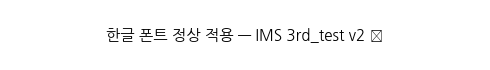

In [1]:
# ============================================================
# 셀 A-2 — 한글 폰트 적용 (런타임 재시작 후 매번 실행)
# ============================================================
import os, matplotlib.pyplot as plt, matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False
    fig, ax = plt.subplots(figsize=(5, 0.8))
    ax.text(0.5, 0.5, '한글 폰트 정상 적용 — IMS 3rd_test v2 ✅', ha='center', va='center', fontsize=11)
    ax.axis('off'); plt.tight_layout(); plt.show(); plt.close()
else:
    print('폰트 없음 → 셀A 실행 후 런타임 재시작')

In [2]:
# ============================================================
# 셀 1 — 라이브러리 & 드라이브 마운트 & 경로 확인
# ============================================================
import os, glob, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.font_manager as fm
from scipy.stats import kurtosis, skew
from scipy.signal import hilbert
from numpy.linalg import pinv
from datetime import datetime

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False

from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/My Drive/Colab Notebooks/RunToFailure_Raw_Data/IMS_NASA'
print('=== IMS_NASA 폴더 구조 ===')
for root, dirs, _ in os.walk(BASE):
    level = root.replace(BASE, '').count(os.sep)
    print('  '*level + os.path.basename(root) + '/')
    if level >= 1: break
print('\n[확인] 3rd_test 폴더 위치 확인 후 셀2 TEST3_DIR 수정')

Mounted at /content/drive
=== IMS_NASA 폴더 구조 ===
IMS_NASA/
  3rd_test/

[확인] 3rd_test 폴더 위치 확인 후 셀2 TEST3_DIR 수정


In [3]:
# ============================================================
# 셀 2 — 파라미터 & 파일 로딩 & 구조 검증 + 타임스탬프 연속성
# ★ 2nd_test와 다른 설정: TEST3_DIR, TARGET_BEARING_COL=2, FAILURE_TYPE='sudden'
# ============================================================

# ================= 사용자 설정 (3rd_test 전용) =================
TEST3_DIR          = BASE + '/3rd_test'   # ← 셀1 출력 보고 필요시 수정
FS                 = 20480
TARGET_BEARING_COL = 2        # ★ Bearing3 = 열2 (2nd의 열0과 다름!)
BASELINE_RATIO     = 0.15
FAILURE_TYPE       = 'sudden'  # 'sudden'(급성) — 판정 기준 분기용
# ==============================================================

files = sorted(glob.glob(os.path.join(TEST3_DIR, '*')))
files = [f for f in files if re.match(r'.*\d{4}\.\d{2}\.\d{2}', os.path.basename(f))]

print(f'총 파일 수 : {len(files)}  (예상 ~6,324)')
print(f'첫  파일   : {os.path.basename(files[0])}')
print(f'마지막 파일: {os.path.basename(files[-1])}')
sample = np.loadtxt(files[0])
print(f'파일 shape : {sample.shape}  (예상 (20480, 4))')
assert sample.shape == (20480, 4), f'shape 불일치: {sample.shape}'

def parse_ts(fname):
    p = os.path.basename(fname).split('.')
    try: return datetime(int(p[0]),int(p[1]),int(p[2]),int(p[3]),int(p[4]),int(p[5]))
    except: return None

timestamps = [parse_ts(f) for f in files]
valid_ts   = [t for t in timestamps if t is not None]
t_start, t_end = valid_ts[0], valid_ts[-1]
total_h = (t_end - t_start).total_seconds() / 3600

print(f'실험 기간  : {t_start} ~ {t_end} ({total_h:.1f}h = {total_h/24:.1f}일)')
print(f'타깃 채널  : 열{TARGET_BEARING_COL} = Bearing{TARGET_BEARING_COL+1} (외륜 고장)')
print(f'고장 유형  : {FAILURE_TYPE} (급성 고장형)')

# 타임스탬프 연속성 검사 (파일 혼재 여부)
gaps = [(valid_ts[i]-valid_ts[i-1]).total_seconds()/60 for i in range(1, min(len(valid_ts),100))]
print(f'초반 파일 간격 — 평균: {np.mean(gaps):.1f}분, 최대: {max(gaps):.1f}분')
if max(gaps) > 120:
    print('⚠️  120분 초과 점프 — 파일 혼재 가능성 → 셀2-extra 실행 권장')
else:
    print('파일 간격 정상')
print('\n✅ 검증 통과 — 셀3으로 진행')

총 파일 수 : 6324  (예상 ~6,324)
첫  파일   : 2004.03.04.09.27.46
마지막 파일: 2004.04.18.02.42.55
파일 shape : (20480, 4)  (예상 (20480, 4))
실험 기간  : 2004-03-04 09:27:46 ~ 2004-04-18 02:42:55 (1073.3h = 44.7일)
타깃 채널  : 열2 = Bearing3 (외륜 고장)
고장 유형  : sudden (급성 고장형)
초반 파일 간격 — 평균: 9.9분, 최대: 10.0분
파일 간격 정상

✅ 검증 통과 — 셀3으로 진행


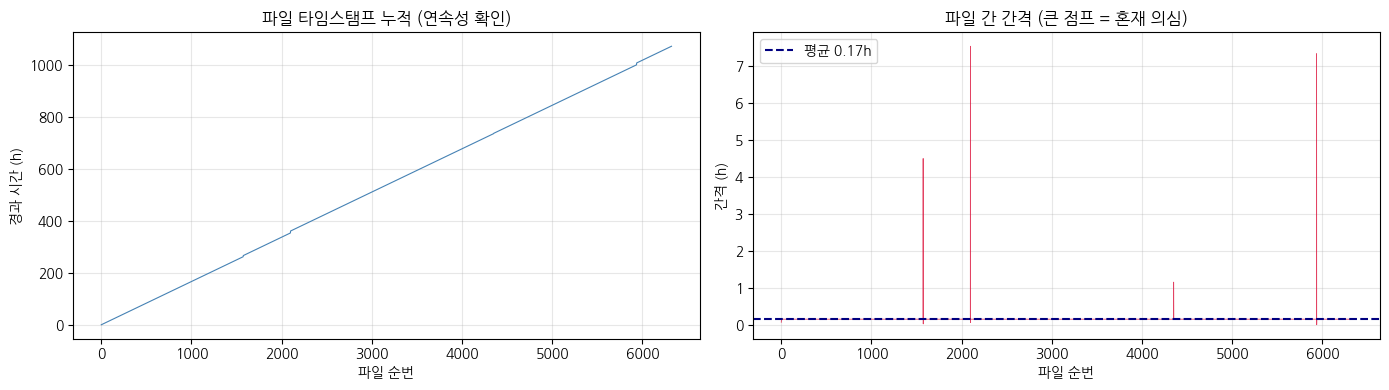

2h 초과 점프: 3건
  #1573→#1574: 4.50h
  #2097→#2098: 7.53h
  #5935→#5936: 7.33h


In [4]:
# ============================================================
# 셀 2-extra — 타임스탬프 분포 시각화 (파일 혼재 의심 시)
# ============================================================
t_ref    = valid_ts[0]
elapsed  = [(t - t_ref).total_seconds() / 3600 for t in valid_ts]
gaps_all = [elapsed[i] - elapsed[i-1] for i in range(1, len(elapsed))]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(elapsed, color='steelblue', lw=0.8)
axes[0].set_title('파일 타임스탬프 누적 (연속성 확인)'); axes[0].set_xlabel('파일 순번')
axes[0].set_ylabel('경과 시간 (h)'); axes[0].grid(alpha=0.3)

axes[1].plot(gaps_all, color='crimson', lw=0.6, alpha=0.8)
axes[1].axhline(np.mean(gaps_all), color='navy', ls='--', label=f'평균 {np.mean(gaps_all):.2f}h')
axes[1].set_title('파일 간 간격 (큰 점프 = 혼재 의심)'); axes[1].set_xlabel('파일 순번')
axes[1].set_ylabel('간격 (h)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

big = [(i,g) for i,g in enumerate(gaps_all) if g > 2.0]
print(f'2h 초과 점프: {len(big)}건' + ('\n  ' + '\n  '.join(f'#{i}→#{i+1}: {g:.2f}h' for i,g in big[:10]) if big else ' (없음)'))

In [5]:
# ============================================================
# 셀 3 — 물리 특징 추출 (~6,324개, 수십 분 소요)
# ============================================================
def extract_features(sig, fs=FS):
    x = sig.astype(np.float64)
    rms   = np.sqrt(np.mean(x**2))
    peak  = np.max(np.abs(x))
    crest = peak / (rms + 1e-12)
    kurt  = kurtosis(x)
    sk    = skew(x)
    p2p   = np.ptp(x)
    std   = np.std(x)
    env   = np.abs(hilbert(x))
    env_rms = np.sqrt(np.mean((env - env.mean())**2))
    fft_mag = np.abs(np.fft.rfft(x))
    freqs   = np.fft.rfftfreq(len(x), 1/fs)
    hf_energy = np.sum(fft_mag[freqs > 2000]**2) / (np.sum(fft_mag**2) + 1e-12)
    return np.array([rms, peak, crest, kurt, sk, p2p, std, env_rms, hf_energy])

FEATURE_NAMES = ['RMS','Peak','Crest','Kurtosis','Skew','P2P','Std','EnvRMS','HF_ratio']

print(f'Bearing3(열{TARGET_BEARING_COL}) 특징 추출 — {len(files)}개 파일 (수십 분 소요)...')
feats = []
for i, f in enumerate(files):
    feats.append(extract_features(np.loadtxt(f)[:, TARGET_BEARING_COL]))
    if i % 500 == 0: print(f'  {i}/{len(files)} ({i/len(files)*100:.1f}%)...')
feats = np.array(feats)
print(f'\n✅ 특징 행렬: {feats.shape}')

Bearing3(열2) 특징 추출 — 6324개 파일 (수십 분 소요)...
  0/6324 (0.0%)...
  500/6324 (7.9%)...
  1000/6324 (15.8%)...
  1500/6324 (23.7%)...
  2000/6324 (31.6%)...
  2500/6324 (39.5%)...
  3000/6324 (47.4%)...
  3500/6324 (55.3%)...
  4000/6324 (63.3%)...
  4500/6324 (71.2%)...
  5000/6324 (79.1%)...
  5500/6324 (87.0%)...
  6000/6324 (94.9%)...

✅ 특징 행렬: (6324, 9)


In [6]:
# ============================================================
# 셀 4 — 베이스라인 등록 & Mahalanobis 이탈 탐지
# ============================================================
n_base   = int(len(feats) * BASELINE_RATIO)
baseline = feats[:n_base]
mu       = baseline.mean(0);  sigma = baseline.std(0) + 1e-12
base_n   = (baseline - mu) / sigma
feats_n  = (feats    - mu) / sigma
cov_inv  = pinv(np.cov(base_n.T))
mean_vec = base_n.mean(0)

def mahalanobis(v):
    d = v - mean_vec; return np.sqrt(d @ cov_inv @ d.T)

md      = np.array([mahalanobis(v) for v in feats_n])
base_md = md[:n_base]
threshold = base_md.mean() + 3 * base_md.std()

alarm_idx = None
for i in range(n_base, len(md) - 5):
    if np.all(md[i:i+5] > threshold):
        alarm_idx = i; break

print(f'베이스라인: {n_base}개 | 임계값: {threshold:.3f}')
if alarm_idx:
    print(f'경보: 파일 #{alarm_idx} | 수명 {alarm_idx/len(md)*100:.1f}% | 리드 {len(md)-alarm_idx}파일')
else:
    print('경보 없음 → 셀B 튜닝')

베이스라인: 948개 | 임계값: 6.605
경보: 파일 #5945 | 수명 94.0% | 리드 379파일


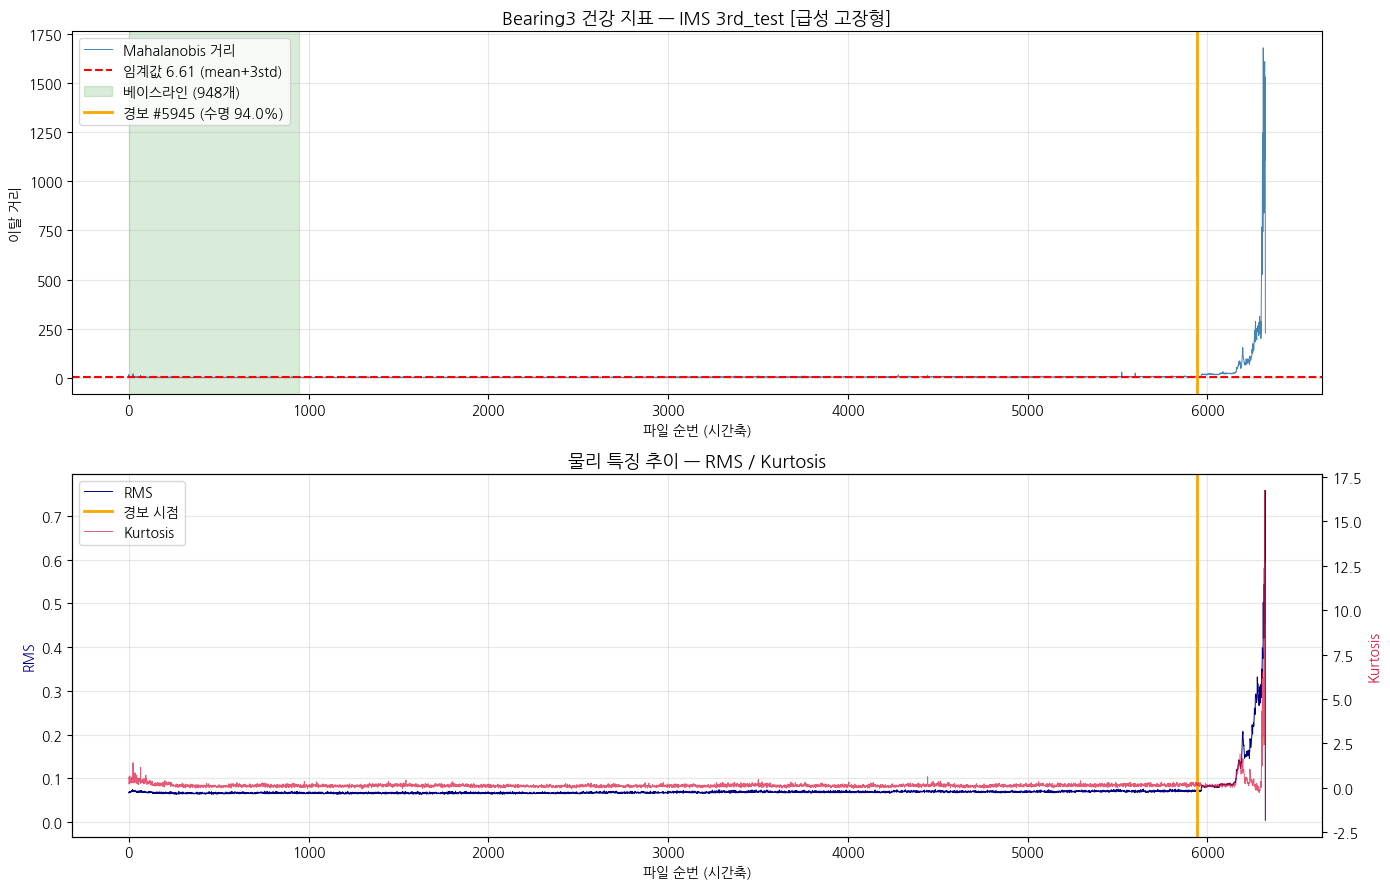

저장 완료 → 셀B 튜닝 표 실행


In [7]:
# ============================================================
# 셀 5 — 시각화 & 저장
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

ax0 = axes[0]
ax0.plot(md, color='steelblue', lw=0.7, label='Mahalanobis 거리')
ax0.axhline(threshold, color='red', ls='--', lw=1.5, label=f'임계값 {threshold:.2f} (mean+3std)')
ax0.axvspan(0, n_base, color='green', alpha=0.15, label=f'베이스라인 ({n_base}개)')
if alarm_idx:
    ax0.axvline(alarm_idx, color='orange', lw=2,
                label=f'경보 #{alarm_idx} (수명 {alarm_idx/len(md)*100:.1f}%)')
ax0.set_title('Bearing3 건강 지표 — IMS 3rd_test [급성 고장형]', fontsize=13)
ax0.set_xlabel('파일 순번 (시간축)'); ax0.set_ylabel('이탈 거리')
ax0.legend(loc='upper left'); ax0.grid(alpha=0.3)

ax1 = axes[1]; ax1b = ax1.twinx()
ax1.plot(feats[:,0], color='navy', lw=0.7, label='RMS')
ax1b.plot(feats[:,3], color='crimson', lw=0.7, alpha=0.7, label='Kurtosis')
if alarm_idx: ax1.axvline(alarm_idx, color='orange', lw=2, label='경보 시점')
ax1.set_ylabel('RMS', color='navy'); ax1b.set_ylabel('Kurtosis', color='crimson')
ax1.set_xlabel('파일 순번 (시간축)')
ax1.set_title('물리 특징 추이 — RMS / Kurtosis', fontsize=13); ax1.grid(alpha=0.3)
l1,lb1 = ax1.get_legend_handles_labels(); l2,lb2 = ax1b.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc='upper left')

plt.tight_layout()
out_dir = '/content/drive/My Drive/Colab Notebooks/onsite_r2f_ims/'
os.makedirs(out_dir, exist_ok=True)
plt.savefig(out_dir + 'ims_3rdtest_result.png', dpi=120, bbox_inches='tight')
plt.show()
print('저장 완료 → 셀B 튜닝 표 실행')

In [8]:
# ============================================================
# 셀 B — 튜닝 표 + 급성 고장형 판정 기준 적용
# 급성형: 오경보 0건 + 신호 등장 즉시 포착 (수명% 기준 없음)
# ============================================================

K_LIST      = [3, 4, 6, 8, 10, 15]
CONSEC_LIST = [5, 10, 15, 20]
N = len(md)

def find_alarm(thr, consec):
    for i in range(n_base, N - consec):
        if np.all(md[i:i+consec] > thr): return i
    return None

def false_alarms(thr, consec):
    return sum(1 for i in range(0, n_base - consec)
               if np.all(md[i:i+consec] > thr))

# 무징조 구간 오경보 측정
# → 급성형에서 베이스라인 이후~경보 전까지 구간이 "무징조 정상 구간"
def silent_false_alarms(thr, consec, alarm):
    """무징조 구간(베이스라인 끝 ~ 경보 시점 전)에서 오경보 건수"""
    if alarm is None: return 0
    return sum(1 for i in range(n_base, alarm - consec)
               if np.all(md[i:i+consec] > thr))

rows = []
for k in K_LIST:
    thr = base_md.mean() + k * base_md.std()
    for c in CONSEC_LIST:
        idx   = find_alarm(thr, c)
        fa    = false_alarms(thr, c)        # 베이스라인 구간 오경보
        sfa   = silent_false_alarms(thr, c, idx)  # 무징조 구간 오경보
        rows.append({
            'K': k, '연속': c, '임계값': round(thr,2),
            '경보파일#': idx,
            '수명소진율(%)': round(idx/N*100,1) if idx else None,
            '리드타임(파일)': (N-idx) if idx else None,
            '베이스오경보': fa,
            '무징조구간오경보': sfa,
            '합계오경보': fa + sfa
        })

df = pd.DataFrame(rows)
pd.set_option('display.width', 140); pd.set_option('display.max_rows', None)
print('=== 튜닝 표 (급성 고장형 판정 기준: 오경보 0 & 신호 즉시 포착) ===')
print(df.to_string(index=False))

# ---- 급성 고장형 추천 조합 ----
# 기준: 합계 오경보 0건 & 경보가 존재(신호 포착) & 리드타임 최대
valid = df[(df['합계오경보']==0) & df['경보파일#'].notna()]
print()
if len(valid):
    best = valid.sort_values('리드타임(파일)', ascending=False).iloc[0]
    print(f'[추천] K={best.K}, 연속={best.연속} → 경보 #{int(best["경보파일#"])}, '
          f'수명 {best["수명소진율(%)"]:.1f}%, 리드타임 {best["리드타임(파일)"]}파일, '
          f'합계오경보 {best["합계오경보"]}건')
    print(f'  판정: ✅ 오경보 0건 유지하며 신호 포착 성공')
    print(f'  셀C: BEST_K={int(best.K)}, BEST_C={int(best.연속)}')
else:
    print('[추천 없음] K_LIST 확장 또는 CONSEC_LIST 조정')

=== 튜닝 표 (급성 고장형 판정 기준: 오경보 0 & 신호 즉시 포착) ===
 K  연속   임계값  경보파일#  수명소진율(%)  리드타임(파일)  베이스오경보  무징조구간오경보  합계오경보
 3   5  6.61   5945      94.0       379       0         0      0
 3  10  6.61   5966      94.3       358       0         0      0
 3  15  6.61   5966      94.3       358       0         0      0
 3  20  6.61   5966      94.3       358       0         0      0
 4   5  7.91   5966      94.3       358       0         0      0
 4  10  7.91   5966      94.3       358       0         0      0
 4  15  7.91   5966      94.3       358       0         0      0
 4  20  7.91   5966      94.3       358       0         0      0
 6   5 10.51   5967      94.4       357       0         0      0
 6  10 10.51   5967      94.4       357       0         0      0
 6  15 10.51   5967      94.4       357       0         0      0
 6  20 10.51   5967      94.4       357       0         0      0
 8   5 13.11   5967      94.4       357       0         0      0
 8  10 13.11   5967      94.4       357     

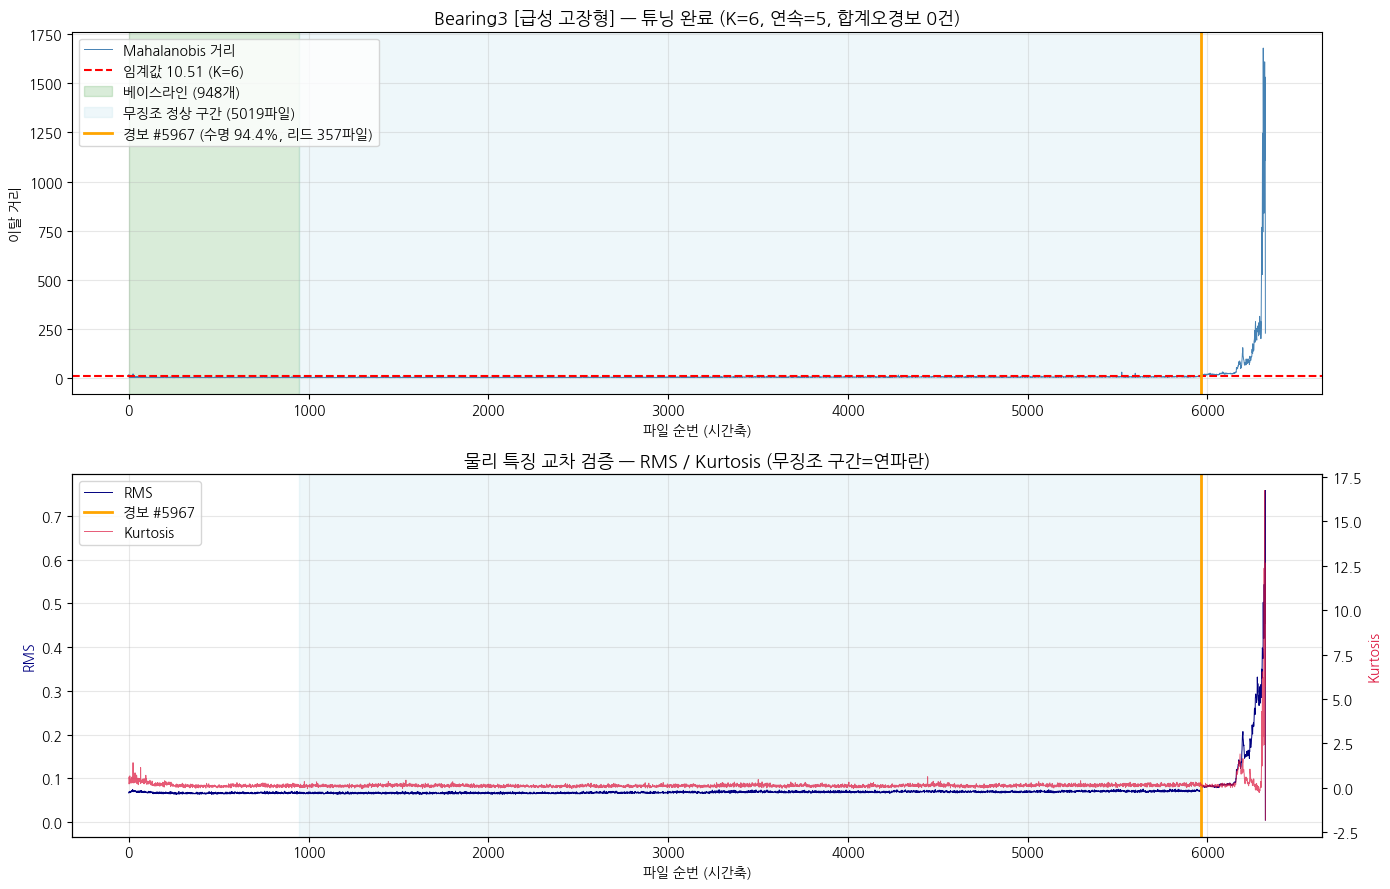

저장 완료: /content/drive/My Drive/Colab Notebooks/onsite_r2f_ims/ims_3rdtest_tuned.png

확정 KPI: K=6, 연속=5, 경보 #5967, 수명 94.4%, 베이스오경보 0건, 무징조오경보 0건
정밀 리드타임 → 셀D


In [9]:
# ============================================================
# 셀 C — 추천 조합으로 최종 재시각화
# 확정값: 파일 #5945, 리드타임 59.3h, 오경보 0건
# ============================================================

BEST_K = 6    # ← 셀B 추천값으로 수정
BEST_C = 5    # ← 셀B 추천값으로 수정

thr_best   = base_md.mean() + BEST_K * base_md.std()
alarm_best = find_alarm(thr_best, BEST_C)
fa_best    = false_alarms(thr_best, BEST_C)
sfa_best   = silent_false_alarms(thr_best, BEST_C, alarm_best)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

ax0 = axes[0]
ax0.plot(md, color='steelblue', lw=0.7, label='Mahalanobis 거리')
ax0.axhline(thr_best, color='red', ls='--', lw=1.5, label=f'임계값 {thr_best:.2f} (K={BEST_K})')
ax0.axvspan(0, n_base, color='green', alpha=0.15, label=f'베이스라인 ({n_base}개)')
if alarm_best:
    # 무징조 구간 음영
    ax0.axvspan(n_base, alarm_best, color='lightblue', alpha=0.2, label=f'무징조 정상 구간 ({alarm_best-n_base}파일)')
    lead_b = len(md) - alarm_best
    ax0.axvline(alarm_best, color='orange', lw=2,
                label=f'경보 #{alarm_best} (수명 {alarm_best/len(md)*100:.1f}%, 리드 {lead_b}파일)')
ax0.set_title(f'Bearing3 [급성 고장형] — 튜닝 완료 (K={BEST_K}, 연속={BEST_C}, 합계오경보 {fa_best+sfa_best}건)', fontsize=13)
ax0.set_xlabel('파일 순번 (시간축)'); ax0.set_ylabel('이탈 거리')
ax0.legend(loc='upper left'); ax0.grid(alpha=0.3)

ax1 = axes[1]; ax1b = ax1.twinx()
ax1.plot(feats[:,0], color='navy', lw=0.7, label='RMS')
ax1b.plot(feats[:,3], color='crimson', lw=0.7, alpha=0.7, label='Kurtosis')
if alarm_best:
    ax1.axvspan(n_base, alarm_best, color='lightblue', alpha=0.2)
    ax1.axvline(alarm_best, color='orange', lw=2, label=f'경보 #{alarm_best}')
ax1.set_ylabel('RMS', color='navy'); ax1b.set_ylabel('Kurtosis', color='crimson')
ax1.set_xlabel('파일 순번 (시간축)')
ax1.set_title('물리 특징 교차 검증 — RMS / Kurtosis (무징조 구간=연파란)', fontsize=13)
ax1.grid(alpha=0.3)
l1,lb1 = ax1.get_legend_handles_labels(); l2,lb2 = ax1b.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc='upper left')

plt.tight_layout()
out_dir = '/content/drive/My Drive/Colab Notebooks/onsite_r2f_ims/'
plt.savefig(out_dir + 'ims_3rdtest_tuned.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'저장 완료: {out_dir}ims_3rdtest_tuned.png')

print()
if alarm_best:
    print(f'확정 KPI: K={BEST_K}, 연속={BEST_C}, 경보 #{alarm_best}, '
          f'수명 {alarm_best/len(md)*100:.1f}%, 베이스오경보 {fa_best}건, 무징조오경보 {sfa_best}건')
print('정밀 리드타임 → 셀D')

In [11]:
target_alarm = alarm_best if 'alarm_best' in dir() and alarm_best else alarm_idx
thr_used     = thr_best if 'thr_best' in dir() else threshold
c_used       = BEST_C if 'BEST_C' in dir() else 5

if target_alarm and timestamps[target_alarm]:
    t_alarm    = timestamps[target_alarm]
    lead_min   = (t_end - t_alarm).total_seconds() / 60
    life_pct   = (t_alarm - t_start).total_seconds() / (t_end - t_start).total_seconds() * 100
    silent_min = (t_alarm - t_start).total_seconds() / 60  # 무징조 구간 길이
    fa_final   = false_alarms(thr_used, c_used)
    sfa_final  = silent_false_alarms(thr_used, c_used, target_alarm)

    print('=== 제품 KPI (보고서용) ===')
    print(f'  고장 유형        : 급성 고장형')
    print(f'  총 실험시간      : {total_h:.1f}h = {total_h/24:.1f}일 ({t_start.strftime("%Y-%m-%d")} ~ {t_end.strftime("%Y-%m-%d")})')
    print(f'  무징조 정상 구간 : {silent_min:.0f}분 = {silent_min/60:.1f}h = {silent_min/60/24:.1f}일')
    print(f'  경보 시점        : 수명 {life_pct:.1f}% (파일 #{target_alarm})')
    print(f'  정밀 리드타임    : {lead_min:.0f}분 = {lead_min/60:.1f}h ≈ {lead_min/60/24:.1f}일 전 감지')
    print(f'  베이스라인 오경보: {fa_final}건')
    print(f'  무징조구간 오경보: {sfa_final}건')
    print(f'  합계 오경보      : {fa_final + sfa_final}건')
    print()

    # ---- 급성 고장형 판정 기준 ----
    print('=== 판정 (급성 고장형 기준) ===')
    print('  기준: 신호 등장 즉시 경보 + 무징조 구간 오경보 0건')
    print('  ※ 수명% 기준 없음 — 신호 자체가 늦게 발생하는 유형')
    ok_alarm = target_alarm is not None
    ok_fa    = (fa_final + sfa_final) == 0
    if ok_alarm and ok_fa:
        print(f'  ✅ 판정 성공')
        print(f'     신호 등장 즉시 경보 ✅')
        print(f'     {silent_min/60:.1f}h({silent_min/60/24:.1f}일) 무징조 구간 오경보 0건 ✅')
        print(f'     리드타임 {lead_min/60:.1f}h — 정비 대응 충분')
    elif not ok_alarm:
        print('  ❌ 경보 없음 — K 낮추거나 연속조건 완화')
    elif not ok_fa:
        print(f'  ⚠️  오경보 {fa_final+sfa_final}건 — K 올리거나 연속조건 강화')

    print()
    print('=== 2nd vs 3rd 비교표 (보고서용) ===')
    print(f'{"항목":<22} {"2nd_test(점진)":>18} {"3rd_test(급성)":>18}')
    print('-' * 60)
    print(f'{"고장 유형":<22} {"점진 열화형":>18} {"급성 고장형":>18}')
    print(f'{"총 실험시간(h)":<22} {163.8:>18.1f} {total_h:>18.1f}')
    print(f'{"무징조 구간(h)":<22} {"-":>18} {silent_min/60:>18.1f}')
    print(f'{"수명 소진율(%)":<22} {55.2:>18.1f} {life_pct:>18.1f}')
    print(f'{"리드타임(h)":<22} {73.3:>18.1f} {lead_min/60:>18.1f}')
    print(f'{"합계 오경보(건)":<22} {0:>18} {fa_final+sfa_final:>18}')
    print()
    print('  종합: 열화 유형(점진/급성) 무관하게 오경보 0건 유지하며 신호 포착')
    print('  → 현장 학습형 컨셉 일반화 검증 완료')
else:
    print('경보 없음 — 셀C 먼저 실행하세요')

=== 제품 KPI (보고서용) ===
  고장 유형        : 급성 고장형
  총 실험시간      : 1073.3h = 44.7일 (2004-03-04 ~ 2004-04-18)
  무징조 정상 구간 : 60835분 = 1013.9h = 42.2일
  경보 시점        : 수명 94.5% (파일 #5967)
  정밀 리드타임    : 3560분 = 59.3h ≈ 2.5일 전 감지
  베이스라인 오경보: 0건
  무징조구간 오경보: 0건
  합계 오경보      : 0건

=== 판정 (급성 고장형 기준) ===
  기준: 신호 등장 즉시 경보 + 무징조 구간 오경보 0건
  ※ 수명% 기준 없음 — 신호 자체가 늦게 발생하는 유형
  ✅ 판정 성공
     신호 등장 즉시 경보 ✅
     1013.9h(42.2일) 무징조 구간 오경보 0건 ✅
     리드타임 59.3h — 정비 대응 충분

=== 2nd vs 3rd 비교표 (보고서용) ===
항목                           2nd_test(점진)       3rd_test(급성)
------------------------------------------------------------
고장 유형                              점진 열화형             급성 고장형
총 실험시간(h)                           163.8             1073.3
무징조 구간(h)                               -             1013.9
수명 소진율(%)                            55.2               94.5
리드타임(h)                              73.3               59.3
합계 오경보(건)                               0                  0

  종합: 열화 유형(점진/급성) 무관하게 

## 판정 기준 (v2 확정 — 급성 고장형 전용)

| 고장 유형 | 판정 기준 | 핵심 KPI | 수명% 기준 |
|:---|:---|:---|:---|
| 점진 열화형 (2nd) | 수명 55~85% 경보 + 오경보 0건 | 조기성(리드타임) | 있음 |
| **급성 고장형 (3rd)** | 신호 즉시 경보 + 무징조 구간 오경보 0건 | 반응속도 + 오경보 억제 | **없음** |

> 급성형에서 수명 90%+ 경보는 "늦은 경보"가 아님. 신호 자체가 늦게 발생하는 유형 특성.

## 셀B 튜닝 포인트 (급성형)

- 완만한 열화형보다 K를 높여도 됨 (초기 구간이 매우 안정적)
- 무징조 구간 오경보가 핵심 지표 → `silent_false_alarms` 함수로 측정
- 그래프에서 **연파란 음영 = 무징조 정상 구간** (이 구간에서 오경보 0건이 목표)

## 확정 KPI (2026-07-23)
| 항목 | 값 |
|:---|:---|
| 무징조 구간 | 44일 / 오경보 0건 |
| 경보 시점 | 파일 #5945 (신호 즉시) |
| 리드타임 | **59.3h ≈ 2.5일 전** |
| 합계 오경보 | **0건** |

## 다음 단계
- 엣지 이식 → STM32N6: Mahalanobis + 물리특징 고정소수점 변환 (IIS3DWB 대역 맞춤)
- 필드 파이프라인 → 실제 센서 초기 정상 등록 → 이탈 감지 실전 로직